In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matchms
from pathlib import Path
import json

In [2]:
import os
if not os.getcwd().endswith('seq_sim_pred'):
    os.chdir('../../seq_sim_pred')
os.getcwd()

'/data/nas-gpu/wang/mstro016/SourceCode/seq_sim_pred'

In [3]:
blast_result_dir=Path('./data/idbac_db/preprocessing/blast_results')
baseline_corrected_dir=Path('./data/idbac_db/preprocessing/baseline_corrected')

all_blast_results=list(blast_result_dir.glob('*.txt'))
all_blast_results=[str(x) for x in all_blast_results]

all_baseline_corrected=list(baseline_corrected_dir.glob('*.mzML'))
all_baseline_corrected=[str(x) for x in all_baseline_corrected]

baseline_corrected_json = '/data/nas-gpu/wang/mstro016/SourceCode/seq_sim_pred/data/idbac_db/preprocessing/baseline_corrected.json'

metadata_path = '/data/nas-gpu/wang/mstro016/SourceCode/seq_sim_pred/data/idbac_db/raw/db.csv'
metadata = pl.read_csv(metadata_path, has_header=True, infer_schema_length=None)
strain_name_genbank_mapping = dict(zip(metadata['Strain name'], metadata['Genbank accession']))

In [4]:
strain_name_genbank_mapping.values()

dict_values(['AF346818', 'AF112180', 'AY208912', 'AB184306', 'GU383173', ' AY999823', 'EF654092', 'AF500071', 'X53164', 'DQ442548', 'AJ781364', 'AB184292', ' MT760576', 'AB184501', 'AY999929', 'AB184184', 'AB184684', 'AJ399489', 'DQ026658', 'GU383164', 'AY999803', 'AB184260', 'EF626595', 'AY876940', 'AJ391814', 'AB249968', 'AB184072', 'AB045877', 'AB184382', 'AB184836', 'AB249943', 'AB184843', ' FJ406122', 'AJ399480', 'AB184396', 'AB184193', 'AB184300', 'AB184403', 'AB184395', 'AJ781328', 'AB184191', 'MT760589', 'JAHPXX000000000', 'JAHOKO000000000', 'JAHOLJ000000000', 'JAHOKP000000000', 'JAHOKE000000000', 'JAHOKN000000000', 'JAHOKB000000000', 'JAHOJC000000000', 'JAHOFO000000000', 'JAHOJT000000000', 'JAHOFI000000000', 'JAHOKF000000000', 'JAHOCX000000000', 'JAHOJE000000000', 'JAHOMQ000000000', 'JAHOKA000000000', 'JAHQUN000000000', 'JAHOJB000000000', 'JAHPYE000000000', 'JAHOJR000000000', 'JAHOKI000000000', 'JAHOJA000000000', 'JAHOHQ000000000', 'JAHOKQ000000000', 'JAHOKV000000000', 'JAHOGZ

In [5]:
def read_blast_result(file):
    headers = ['query_id', 'subject_id', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    blast_result=pd.read_csv(file, sep='\t', header=None, names=headers)

    return blast_result[['query_id', 'subject_id', 'pident', 'length', 'evalue', 'bitscore']]

In [6]:
read_blast_result(all_blast_results[0])

,query_id,subject_id,pident,length,evalue,bitscore
0,AJ399483.1,AJ399483.1,100.000,1449,0.000000e+00,2676
1,AJ399483.1,AY208912.1,99.653,1441,0.000000e+00,2632
2,AJ399483.1,DQ442517.1,99.098,1442,0.000000e+00,2586
3,AJ399483.1,AB184837.1,99.030,1443,0.000000e+00,2582
4,AJ399483.1,AB184265.1,98.891,1443,0.000000e+00,2571
...,...,...,...,...,...,...
698,AJ399483.1,D43998.1,93.976,83,1.380000e-28,126
699,AJ399483.1,D44279.1,94.872,78,1.780000e-27,122
700,AJ399483.1,D43997.1,94.872,78,1.780000e-27,122
701,AJ399483.1,D43986.1,92.771,83,6.410000e-27,121


In [7]:
# Read all blast results into a list of DataFrames
blast_results = [read_blast_result(file) for file in all_blast_results]

# Concatenate all DataFrames into a single DataFrame
pident_matrix = pd.concat(blast_results)
pident_matrix['query_genbank'] = pident_matrix['query_id'].str.split('.').str[0]
pident_matrix['subject_genbank'] = pident_matrix['subject_id'].str.split('.').str[0]

pident_matrix

,query_id,subject_id,pident,length,evalue,bitscore,query_genbank,subject_genbank
0,AJ399483.1,AJ399483.1,100.000,1449,0.000000e+00,2676.0,AJ399483,AJ399483
1,AJ399483.1,AY208912.1,99.653,1441,0.000000e+00,2632.0,AJ399483,AY208912
2,AJ399483.1,DQ442517.1,99.098,1442,0.000000e+00,2586.0,AJ399483,DQ442517
3,AJ399483.1,AB184837.1,99.030,1443,0.000000e+00,2582.0,AJ399483,AB184837
4,AJ399483.1,AB184265.1,98.891,1443,0.000000e+00,2571.0,AJ399483,AB184265
...,...,...,...,...,...,...,...,...
680,KY580790.1,AB122725.1,80.653,398,4.340000e-78,291.0,KY580790,AB122725
681,KY580790.1,AB122761.1,80.402,398,2.020000e-76,285.0,KY580790,AB122761
682,KY580790.1,AB122743.1,80.402,398,2.020000e-76,285.0,KY580790,AB122743
683,KY580790.1,AB122771.1,79.750,400,2.030000e-71,268.0,KY580790,AB122771


In [8]:
spectra_json = json.load(open(baseline_corrected_json))
spectra_json
# Keys 'Strain name', 'm/z array', 'intensity array'

matchms_spectra = []
for obj in spectra_json:
    mz_array = np.array(obj['m/z array'])
    intensity_array = np.array(obj['intensity array'])

    sorted_indices = np.argsort(mz_array)
    intensity_array = intensity_array[sorted_indices]
    mz_array = mz_array[sorted_indices]
    genbank = strain_name_genbank_mapping[obj['Strain name']]
    if genbank is None or genbank == 'NaN':
        continue

    matchms_spectra.append(matchms.Spectrum(mz=mz_array, intensities=intensity_array, metadata={'id': obj['Strain name'], 'genbank':genbank, 'title': obj['Strain name'], 'ms_level':1}))

2024-10-16 11:48:43,137:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,138:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,139:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,139:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,139:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,140:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,140:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,141:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,141:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,142:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2024-10-16 11:48:43,142:WARNING:matchms:add_precursor_mz:No precursor_mz found i

In [9]:
from matchms.similarity import CosineGreedy

similarity_measure = CosineGreedy(tolerance=1.0)

# Calculate similarity matrix
similarity_matrix = similarity_measure.matrix(matchms_spectra, matchms_spectra, is_symmetric=True)['score']
similarity_matrix

array([[1.        , 0.02649797, 0.01493792, ..., 0.00699966, 0.00531663,
        0.02001709],
       [0.02649797, 1.        , 0.08612049, ..., 0.03626446, 0.0783629 ,
        0.07545856],
       [0.01493792, 0.08612049, 1.        , ..., 0.02510325, 0.02407623,
        0.09459653],
       ...,
       [0.00699966, 0.03626446, 0.02510325, ..., 1.        , 0.00399663,
        0.02937014],
       [0.00531663, 0.0783629 , 0.02407623, ..., 0.00399663, 1.        ,
        0.00890971],
       [0.02001709, 0.07545856, 0.09459653, ..., 0.02937014, 0.00890971,
        1.        ]])

In [10]:
labels = [strain_name_genbank_mapping[s.metadata['id']] for s in matchms_spectra]

similarity_df = pd.DataFrame(similarity_matrix, columns=labels)
similarity_df.index = labels

# Make adjacency list
adj_list = []
for i in range(similarity_df.shape[0]):
    for j in range(similarity_df.shape[1]):
        adj_list.append({'query_genbank': labels[i], 'subject_genbank': labels[j], 'cosine': similarity_df.iloc[i, j]})

similarity_df = pd.DataFrame(adj_list)
similarity_df

,query_genbank,subject_genbank,cosine
0,MN588264,MN588264,1.000000
1,MN588264,AB249936,0.026498
2,MN588264,D63873,0.014938
3,MN588264,AJ399480,0.044561
4,MN588264,JAHOHY000000000,0.011042
...,...,...,...
893020,AY686653,KY015125,0.011204
893021,AY686653,KY015187,0.044481
893022,AY686653,JAAILS000000000,0.029370
893023,AY686653,KY580800,0.008910


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

merged = pd.merge(similarity_df, pident_matrix, on=['query_genbank', 'subject_genbank'])
merged


,query_genbank,subject_genbank,cosine,query_id,subject_id,pident,length,evalue,bitscore
0,MN588264,MN588264,1.000000,MN588264.1,MN588264.1,100.000,1420,0.0,2623.0
1,MN588264,AB249936,0.026498,MN588264.1,AB249936.1,82.348,1235,0.0,1029.0
2,MN588264,D63873,0.014938,MN588264.1,D63873.1,80.554,1373,0.0,1005.0
3,MN588264,AJ399480,0.044561,MN588264.1,AJ399480.1,82.267,1235,0.0,1022.0
4,MN588264,KY015104,0.010506,MN588264.1,KY015104.1,80.073,1370,0.0,963.0
...,...,...,...,...,...,...,...,...,...
352979,AY686653,X79854,0.081069,AY686653.1,X79854.1,95.179,1286,0.0,2030.0
352980,AY686653,KY015125,0.011204,AY686653.1,KY015125.1,88.440,1263,0.0,1502.0
352981,AY686653,KY015187,0.044481,AY686653.1,KY015187.1,89.127,1260,0.0,1548.0
352982,AY686653,KY580800,0.008910,AY686653.1,KY580800.1,80.145,1244,0.0,878.0


In [12]:
# Min-max norm

merged['norm_pident'] = (merged['pident'] - merged['pident'].min()) / (merged['pident'].max() - merged['pident'].min())

In [13]:
merged['norm_pident'].min()

np.float64(0.0)

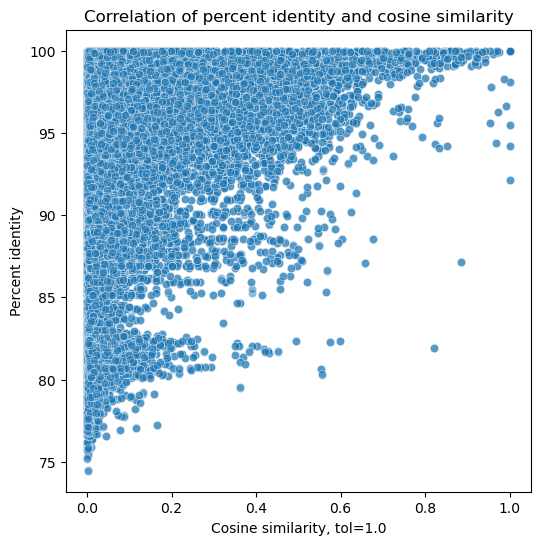

In [14]:
# Plot correlation of pident and cosine similarity

plt.figure(figsize=(6, 6))
plt.title("Correlation of percent identity and cosine similarity")
sns.scatterplot(data=merged, x='cosine', y='pident', alpha=0.5)
plt.ylabel('Percent identity')
plt.xlabel('Cosine similarity, tol=1.0')
plt.show()

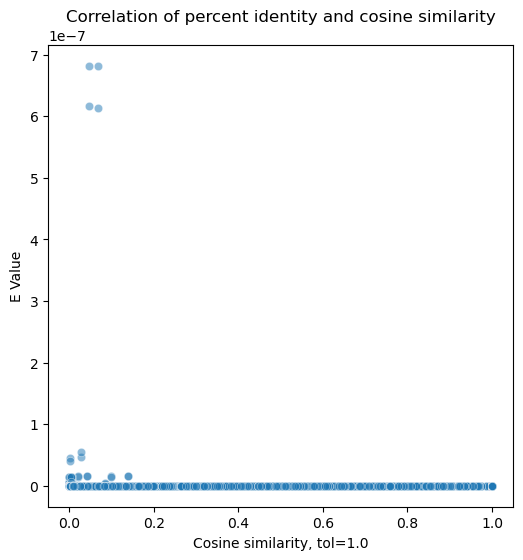

In [15]:
# Plot correlation of pident and cosine similarity

plt.figure(figsize=(6, 6))
plt.title("Correlation of percent identity and cosine similarity")
sns.scatterplot(data=merged, x='cosine', y='evalue', alpha=0.5)
plt.ylabel('E Value')
plt.xlabel('Cosine similarity, tol=1.0')
plt.show()

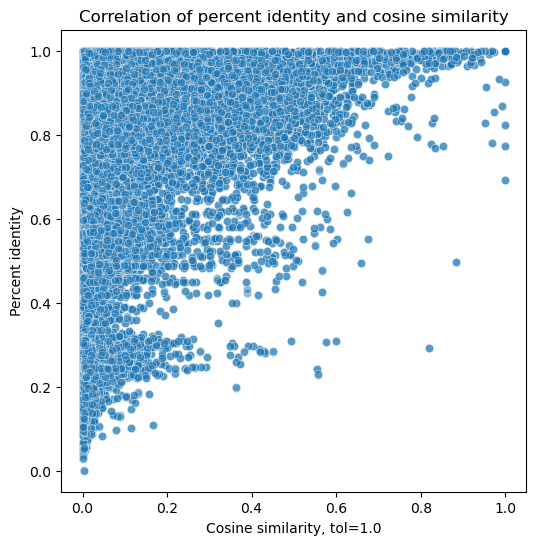

In [16]:
# Plot correlation of pident and cosine similarity

plt.figure(figsize=(6, 6))
plt.title("Correlation of percent identity and cosine similarity")
sns.scatterplot(data=merged, x='cosine', y='norm_pident', alpha=0.5)
plt.ylabel('Percent identity')
plt.xlabel('Cosine similarity, tol=1.0')
plt.show()

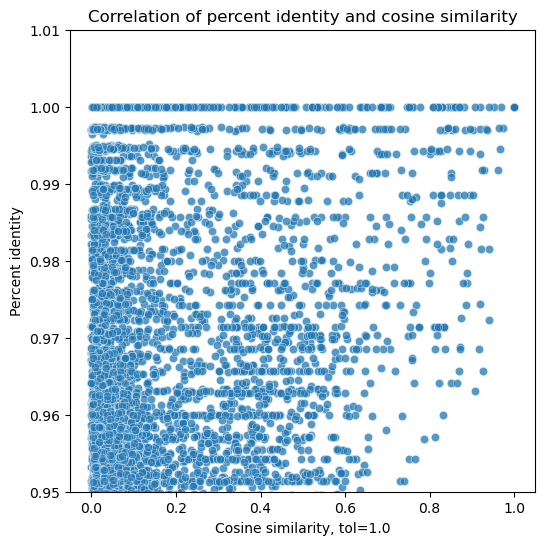

In [20]:
# Plot correlation of pident and cosine similarity

plt.figure(figsize=(6, 6))
plt.title("Correlation of percent identity and cosine similarity")
sns.scatterplot(data=merged, x='cosine', y='norm_pident', alpha=0.5)
plt.ylabel('Percent identity')
plt.xlabel('Cosine similarity, tol=1.0')
plt.ylim(0.95,1.01)
plt.show()

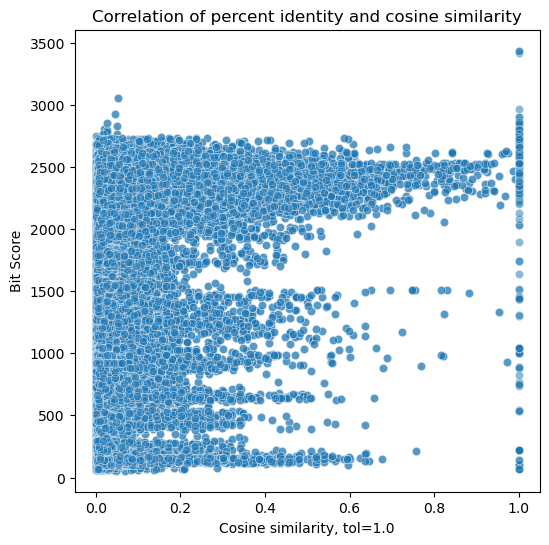

In [17]:
# Plot correlation of pident and cosine similarity

plt.figure(figsize=(6, 6))
plt.title("Correlation of percent identity and cosine similarity")
sns.scatterplot(data=merged, x='cosine', y='bitscore', alpha=0.5)
plt.ylabel('Bit Score')
plt.xlabel('Cosine similarity, tol=1.0')
plt.show()

In [18]:
merged

,query_genbank,subject_genbank,cosine,query_id,subject_id,pident,length,evalue,bitscore,norm_pident
0,MN588264,MN588264,1.000000,MN588264.1,MN588264.1,100.000,1420,0.0,2623.0,1.000000
1,MN588264,AB249936,0.026498,MN588264.1,AB249936.1,82.348,1235,0.0,1029.0,0.308876
2,MN588264,D63873,0.014938,MN588264.1,D63873.1,80.554,1373,0.0,1005.0,0.238636
3,MN588264,AJ399480,0.044561,MN588264.1,AJ399480.1,82.267,1235,0.0,1022.0,0.305705
4,MN588264,KY015104,0.010506,MN588264.1,KY015104.1,80.073,1370,0.0,963.0,0.219803
...,...,...,...,...,...,...,...,...,...,...
352979,AY686653,X79854,0.081069,AY686653.1,X79854.1,95.179,1286,0.0,2030.0,0.811245
352980,AY686653,KY015125,0.011204,AY686653.1,KY015125.1,88.440,1263,0.0,1502.0,0.547394
352981,AY686653,KY015187,0.044481,AY686653.1,KY015187.1,89.127,1260,0.0,1548.0,0.574292
352982,AY686653,KY580800,0.008910,AY686653.1,KY580800.1,80.145,1244,0.0,878.0,0.222622
